In [ ]:
# import all libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import pickle



In [ ]:
# Install the XGBoost library
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Load the dataset containing demand forecasting data.
df = pd.read_csv("datasets/demand_forecasting.csv")

In [48]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [ ]:
# Display all column names in the dataset.
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

In [ ]:
# Define the list of feature variables that will be used to train the machine learning model.
features = [
    "Price",
    "Discount",
    "Inventory Level",
    "Promotion",
    "Competitor Pricing",
    "Category"
]

In [51]:
features

['Price',
 'Discount',
 'Inventory Level',
 'Promotion',
 'Competitor Pricing',
 'Category']

In [ ]:
# Define the target variable the model will learn to predict.
target = "Demand"

In [ ]:
# Create the feature dataset (X) from the original dataframe.
x = df[features].copy()

In [54]:
x

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,Electronics
1,80.16,15,117,1,92.02,Clothing
2,62.94,10,247,1,60.08,Clothing
3,87.63,10,139,0,85.19,Electronics
4,54.41,0,152,0,51.63,Groceries
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,Toys
75996,42.92,5,137,0,40.73,Toys
75997,17.81,10,197,0,19.41,Clothing
75998,151.72,0,125,0,143.71,Furniture


In [ ]:
# Extract the target variable from the dataset to represent the value to be predicted.
y = df[target]

In [56]:
y

0        115
1        229
2        157
3         52
4         59
        ... 
75995     64
75996    137
75997     68
75998     84
75999     73
Name: Demand, Length: 76000, dtype: int64

In [ ]:
# Create an empty dictionary to store label encoders. 
label_encoders = {}
# Identify categorical column in the dataset.
categorical_cols = x.select_dtypes(include ="object").columns

In [58]:
categorical_cols

Index(['Category'], dtype='object')

In [ ]:
# Loop through each categorical column and apply label encoding.
for col in categorical_cols:
    le = LabelEncoder()
    x[col]= le.fit_transform(x[col])
    label_encoders[col] = le

In [60]:
label_encoders

{'Category': LabelEncoder()}

In [ ]:
# Split the dataset into training and testing sets. 80% used for training and 20% for testing.
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2)

In [62]:
x

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,1
1,80.16,15,117,1,92.02,0
2,62.94,10,247,1,60.08,0
3,87.63,10,139,0,85.19,1
4,54.41,0,152,0,51.63,3
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,4
75996,42.92,5,137,0,40.73,4
75997,17.81,10,197,0,19.41,0
75998,151.72,0,125,0,143.71,2


In [ ]:
# Initialise the XGBoost regression model for regression tasks using squared error loss.
xgb = XGBRegressor(objective="reg:squarederror", n_jobs=-1)

In [ ]:
# Define a dictionary containing hyperparameters
param_dict = {
    "n_estimators":[100,200,300,500],
    "max_depth": [3,4,6,8],
    "learning_rate":[0.01,0.1,0.15,0.2],
    "subsample":[0.7,0.8,1.0],
    "colsample_bytree":[0.7,0.8,1.0],
    "min_child_weight":[1,3,5]
}

In [ ]:
# Apply RandomizedSearchCV to perform hyperparameter tuning for improving model performance
random_search = RandomizedSearchCV(
    estimator = xgb,
    param_distributions = param_dict,
    n_iter = 25,
    scoring = "neg_mean_absolute_error",
    cv=3,
    verbose = 1,
    n_jobs = -1
)

In [ ]:
# Train the model using the training dataset.
random_search.fit(x_train, y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,25
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [67]:
random_search.best_params_

{'subsample': 1.0,
 'n_estimators': 100,
 'min_child_weight': 3,
 'max_depth': 8,
 'learning_rate': 0.1,
 'colsample_bytree': 1.0}

In [ ]:
# Display the best hyperparameter combination discovered during tuning.
best_model = random_search.best_estimator_

In [ ]:
# Use the trained model to make predictions on the test dataset.
y_pred = best_model.predict(x_test)

In [ ]:
# Use RMSE to measure the difference between predicted and actual values.
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(35.45509098229054)

In [ ]:
# Retrieve feature importance scores from the trained model.
best_model.feature_importances_

array([0.0623876 , 0.0168421 , 0.01403087, 0.64365864, 0.01707041,
       0.2460104 ], dtype=float32)

In [ ]:
# Convert feature importance values into a pandas Series
feature_importance = pd.Series(
    best_model.feature_importances_,
    index = x.columns
).sort_values(ascending = False)

In [73]:
feature_importance

Promotion             0.643659
Category              0.246010
Price                 0.062388
Competitor Pricing    0.017070
Discount              0.016842
Inventory Level       0.014031
dtype: float32

<Axes: title={'center': 'Feature Importances'}>

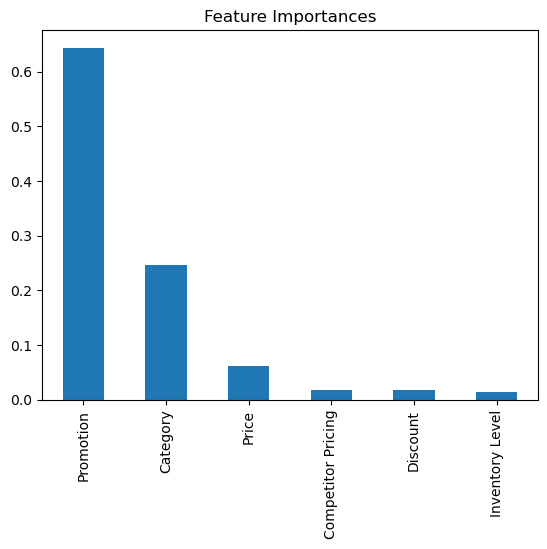

In [ ]:
# Plot a bar chart showing the impact of each feature on the model.
feature_importance.plot(kind='bar', title='Feature Importances')

In [ ]:

# Save the trained label encoders to a file using pickle.
with open ('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

In [ ]:
# Save the trained XGBoost model to a file.
with open ('xgboost_demand_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)